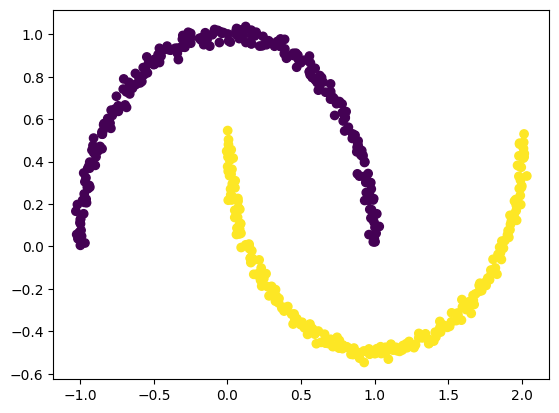

In [2]:
# Create a dataset that is nonlinear ans then apply PCA to the dataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X , y = make_moons(n_samples = 500 , noise = 0.02 , random_state = 417)
plt.scatter(X[: , 0] , X[: , 1] , c = y)
plt.show()

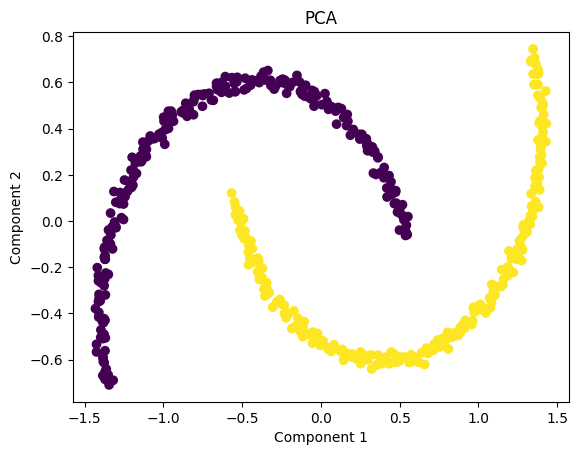

In [4]:
# Let's apply the PCA to this dataset
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca =pca.fit_transform(X)

plt.title("PCA")
plt.scatter(X_pca[: , 0] , X_pca[: , 1] , c = y)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

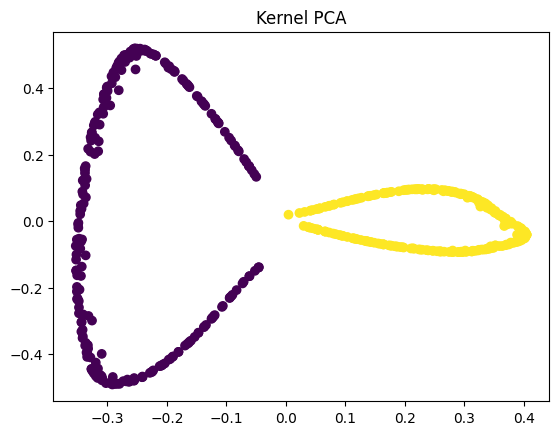

In [5]:
# As you can see PCA failed to distinguish the two classes
# Applying kernel PCA on this dataset with RBF kernel with a gamma valeu of 15
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel = 'rbf' , gamma = 15)
X_kpca = kpca.fit_transform(X)
plt.title("Kernel PCA")
plt.scatter(X_kpca[:,0] , X_kpca[: , 1] , c = y)
plt.show()

In [ ]:
# In the kernel space the two classes are linearly separable. Kernel PCA uses a kernel function 
# to project the dataset into a higher-dimensional space, where it is linearly separable. Finally,
# we applied the kernel PCA to a non-linear dataset using scikit-learn.

In [ ]:
# Selecting a Kernel and Tuning Hyperparameters
#  As kPCA is an unsupervised learning algorithm, there is no obvious performance
#  measure to help you select the best kernel and hyperparameter values. However,
#  dimensionality reduction is often a preparation step for a supervised learning task
#  (e.g., classification), so you can simply use grid search to select the kernel and hyper
# parameters that lead to the best performance on that task. For example, the following
#  code creates a two-step pipeline, first reducing dimensionality to two dimensions
#  using kPCA, then applying Logistic Regression for classification. Then it uses Grid
#  SearchCV to find the best kernel and gamma value for kPCA in order to get the best
#  classification accuracy at the end of the pipeline

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [10]:
import numpy as np
clf = Pipeline([
 ("kpca", KernelPCA(n_components=2)),
 ("log_reg", LogisticRegression())
 ])
param_grid = [{
"kpca__gamma": np.linspace(0.03, 0.05, 10),
"kpca__kernel": ["rbf", "sigmoid"]
}]
grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X, y)
print(grid_search.best_params_)

{'kpca__gamma': np.float64(0.05), 'kpca__kernel': 'rbf'}


# LLE (LOCAL LINEAR EMBEDDING)

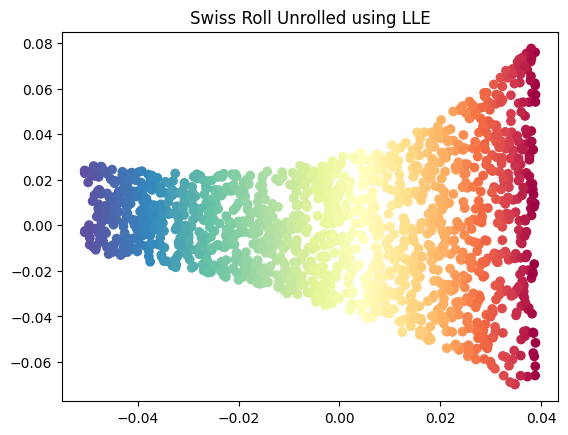

In [11]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
import matplotlib.pyplot as plt

X, t = make_swiss_roll(n_samples=1500, noise=0.05)

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=12)
X_lle = lle.fit_transform(X)

plt.scatter(X_lle[:,0], X_lle[:,1], c=t, cmap='Spectral')
plt.title("Swiss Roll Unrolled using LLE")
plt.show()
